# 1. Pauli Operators

- Fundamental blocks in performing single- and multi-qubit operations.
- Pauli operators are Hermitian (equal to its conjugate transpose) and unitary (conjugate transpose is equal to its inverse)

In [27]:
# Setup: Import necessary libraries
from qiskit.quantum_info import Pauli, ScalarOp
import numpy as np
from qiskit import QuantumCircuit

print("Libraries imported successfully.")

Libraries imported successfully.


#### Initialization



In [28]:
#1. String Representation
p = Pauli('YZXI')

#2. Boolean Representation
z = np.array([False,False,True,True])  
x = np.array([False,True,False,True])  
             #I     X    Z     Y
pauli_array_rep = Pauli((z, x))

#3. Quantum Circuit Representation
qc = QuantumCircuit(4)
qc.id(0)
qc.x(1)
qc.z(2)
qc.y(3)
# Note: pauli op can only be extracted from quantum circuits that only contain pauli gates
pauli_quantum_circuit = Pauli(qc)

print(p, pauli_array_rep, pauli_quantum_circuit)

YZXI YZXI YZXI


In [29]:
#4. Scalar Operations

# ScalarOp - scalar multiple of the id op, can be composed with a pauli op to apply a global phase.
# Pauli can only be multiplied by 1, -1, 1j, -1j
scalar_op = ScalarOp(dims=(2,2,2,2), coeff=-1j)
pauli_scalarop = Pauli('YZXI')
p = scalar_op.compose(pauli_scalarop)
print(p)

-iYZXI


#### Representation

In [27]:
#1. Matrix representation
p = Pauli('-iYZY')
p_matrix = p.to_matrix()
print(p_matrix)

#2. Label representation
print(f"String format:{str(p)}")
print(f"Label format:{p.to_label()}")

# Note: An error occurs when the label function is applied to the matrix variable.

[[ 0.+0.j  0.+0.j  0.+0.j  0.+0.j  0.+0.j  0.+1.j  0.+0.j  0.+0.j]
 [ 0.+0.j  0.+0.j  0.+0.j  0.+0.j -0.-1.j  0.+0.j  0.+0.j  0.+0.j]
 [ 0.+0.j  0.+0.j  0.+0.j  0.+0.j  0.+0.j  0.+0.j  0.+0.j -0.-1.j]
 [ 0.+0.j  0.+0.j  0.+0.j  0.+0.j  0.+0.j  0.+0.j  0.+1.j  0.+0.j]
 [ 0.+0.j -0.-1.j  0.+0.j  0.+0.j  0.+0.j  0.+0.j  0.+0.j  0.+0.j]
 [ 0.+1.j  0.+0.j  0.+0.j  0.+0.j  0.+0.j  0.+0.j  0.+0.j  0.+0.j]
 [ 0.+0.j  0.+0.j  0.+0.j  0.+1.j  0.+0.j  0.+0.j  0.+0.j  0.+0.j]
 [ 0.+0.j  0.+0.j -0.-1.j  0.+0.j  0.+0.j  0.+0.j  0.+0.j  0.+0.j]]
String format:-iYZY
Label format:-iYZY


#### Attributes

In [ ]:
# Access Pauli operator attributes
print(f"Dimension: {p.dim}")  # Dimension of the operator matrix
print(f"Classical bits: {p.num_clbits}, Qubits: {p.num_qubits}")  # Number of qubits
print(f"X: {p.x}, Z: {p.z}, Phase: {p.phase}")  # Components and phase

# Number of classical bits (always 0 for pauli op)
# Phase of op (0, 1, 2, 3 representing +1, -i, -1, i)

Dimension: (8, 8)
Classical bits: 0, Qubits: 3
X: [ True False  True], Z: [ True  True  True], Phase: 1


#### Methods

In [ ]:
# 1. adjoint (conjugate transpose)
# For pauli op, adjoint is the same but phase may change
print(f"Adjoint of {p}: {p.adjoint()}")

# 2. anticommutes (AB = -BA)
# Number of qubits should match
p1 = Pauli('X')      
p2 = Pauli('iZ')     
print(f"{p1} anticommutes with {p2} is {p1.anticommutes(p2)}")

# 3. compose (matrix product of 2 pauli op. returns pauli op with phase)
print(f"{p1} compose with {p2} is {p1.compose(p2)}")

# 4. conjugate (complex conjugate)
# For real pauli op (no imaginary phase), conjugate is the same
print(f"Conjugate of {p} is {p.conjugate()}")

# 5. delete
qubit_index = 0
delete_0 = p.delete(qubit_index)
print(f"{p} after deleting qubit {qubit_index} is {delete_0}")

# 6. insert
qubit_index = 0
insert_0 = delete_0.insert(qubit_index, Pauli('Y'))
print(f"{delete_0} after inserting X at qubit {qubit_index} is {insert_0}")

# 7. instruction
# can be used in quantum circuits
p.to_instruction()

Adjoint of -iYZY: iYZY
X anticommutes with iZ is True
X compose with iZ is -Y
Conjugate of -iYZY is iYZY
-iYZY after deleting qubit 0 is -iYZ
-iYZ after inserting X at qubit 0 is -iYZY


Instruction(name='-iYZY', num_qubits=3, num_clbits=0, params=[])

# 2. Fundamental Gates and Circuits

In [53]:
# Setup: Import necessary libraries
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister
from qiskit.circuit import Parameter, Instruction, Gate
from qiskit.circuit.library import *
import numpy as np
import matplotlib.pyplot as plt

print("Libraries imported successfully.")

Libraries imported successfully.


#### Standard Gates

In [ ]:
# Reversible (1-1 and onto mapping) and unitary quantum gates
# Use Instruction or Gate when performing abstract or mathematical operations
# Use QuantumCircuit when you want to construct the circuit structurally

from qiskit.circuit.library import get_standard_gate_name_mapping
print(f"Standard Gates in Qiskit:{get_standard_gate_name_mapping().keys()}")

Standard Gates in Qiskit:dict_keys(['id', 'sx', 'x', 'cx', 'rz', 'r', 'c3sx', 'ccx', 'dcx', 'ch', 'cp', 'crx', 'cry', 'crz', 'cswap', 'csx', 'cu', 'cu1', 'cu3', 'cy', 'cz', 'ccz', 'global_phase', 'h', 'p', 'rccx', 'rcccx', 'rx', 'rxx', 'ry', 'ryy', 'rzz', 'rzx', 'xx_minus_yy', 'xx_plus_yy', 'ecr', 's', 'sdg', 'cs', 'csdg', 'swap', 'iswap', 'sxdg', 't', 'tdg', 'u', 'u1', 'u2', 'u3', 'y', 'z', 'delay', 'reset', 'measure'])


In [ ]:
# Example of SXGate (single qubit gate)

from qiskit.circuit.library import SXGate
sxgate = SXGate()
print (f"SXGate Matrix:\n{sxgate.to_matrix()}")
print(f"√SX Matrix:\n{sxgate.power(1/2).to_matrix()}")
print(f"CSX Gate:\n{sxgate.control(1).to_matrix()}")
print(f"CSX Gate:\n{sxgate.control(1)}")

SXGate Matrix:
[[0.5+0.5j 0.5-0.5j]
 [0.5-0.5j 0.5+0.5j]]
√SX Matrix:
[[0.85355339+0.35355339j 0.14644661-0.35355339j]
 [0.14644661-0.35355339j 0.85355339+0.35355339j]]
CSX Gate:
[[1. +0.j  0. +0.j  0. +0.j  0. +0.j ]
 [0. +0.j  0.5+0.5j 0. +0.j  0.5-0.5j]
 [0. +0.j  0. +0.j  1. +0.j  0. +0.j ]
 [0. +0.j  0.5-0.5j 0. +0.j  0.5+0.5j]]
CSX Gate:
Instruction(name='csx', num_qubits=2, num_clbits=0, params=[])


In [14]:
# Example of Global Phase Gate (e^iθ is applied to the entire qubit state)

from qiskit.circuit.library import GlobalPhaseGate
import numpy as py
gpgate=GlobalPhaseGate(py.pi)
print (f"Global Phase Matrix:{gpgate}")

Global Phase Matrix:Instruction(name='global_phase', num_qubits=0, num_clbits=0, params=[3.141592653589793])


#### Standard Directives

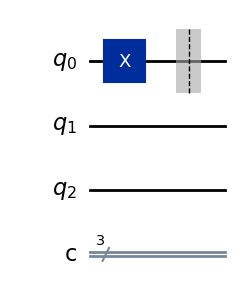

In [ ]:
# Barrier (visually separates different parts of the circuit)
from qiskit.circuit import QuantumCircuit
from qiskit.circuit.library import Barrier, XGate
b = Barrier(1)
qc = QuantumCircuit(3,3)
xgate = XGate()
qc.compose(xgate).compose(b).draw('mpl')

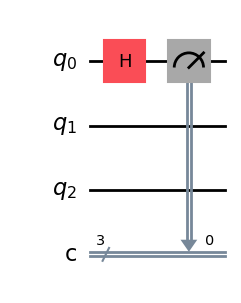

In [17]:
# Measure (performed in computational basis, extracts quantum state and stores it onto a classical bit)

from qiskit.circuit.library import Measure, HGate
measure = Measure()
hgate = HGate()
qc.compose(hgate).compose(measure).draw('mpl')

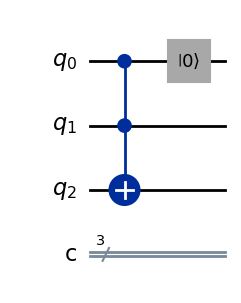

In [18]:
# Reset (Reset a Qubit to |0>)

from qiskit.circuit.library import Reset
reset = Reset()
qc.compose(ccxgate).compose(reset).draw('mpl')

In [30]:
#Vardiac Gates (number of qubits depends on the input)
from qiskit.circuit.library import DiagonalGate

diagonal = DiagonalGate([1, 1j])
print(diagonal.num_qubits)

diagonal = DiagonalGate([1, 1, 1, -1])
print(diagonal.num_qubits)

1
2


#### LinearPauliRotations

`LinearPauliRotations` is a specialized quantum circuit library component. It implements a controlled rotation where the rotation angle is determined by a linear function of the integer value stored in the control qubits.

The circuit applies a rotation $R_{basis}(\theta)$ to the target qubits, where the angle $\theta$ is calculated as:

$$ \theta = \text{slope} \times x + \text{offset} $$

*   **$x$**: The integer value represented by the state (control) qubits.
*   **slope**: The rate of change of the angle per integer step.
*   **offset**: The starting angle when $x = 0$.
*   **basis**: The axis of rotation ($X, Y,$ or $Z$).

In [ ]:
try:
    from qiskit import QuantumCircuit
    from qiskit.circuit.library import LinearPauliRotations
except ImportError:
    print("Error: Qiskit is not installed.")
    exit(1)

def example_linear_pauli_rotations():
    # Parameters for the linear function
    slope = 0.5
    offset = 0.2
    
    # Define the number of state qubits (control) and target qubits
    num_state_qubits = 2
    num_target_qubits = 1
    
    # Create the LinearPauliRotations circuit
    # basis='Y' means we are doing Ry rotations
    lpr_circuit = LinearPauliRotations(
        num_state_qubits=num_state_qubits,
        slope=slope,
        offset=offset,
        basis='Y'
    )
    
    print("--- LinearPauliRotations Circuit ---")
    print(lpr_circuit.draw())
    
    # To see the inner structure (decomposition)
    print("\n--- Decomposed Circuit ---")
    print(lpr_circuit.decompose().draw())

    # Example of integrating into a larger circuit
    print("\n--- Integrated into larger circuit ---")
    qc = QuantumCircuit(num_state_qubits + num_target_qubits)
    
    # Initialize state qubits (e.g., to superposition)
    qc.h(range(num_state_qubits))
    
    # Append the LinearPauliRotations circuit
    # The first 'num_state_qubits' are controls, the last 'num_target_qubits' are targets
    qc.append(lpr_circuit, range(num_state_qubits + num_target_qubits))
    
    print(qc.draw())

if __name__ == "__main__":
    try:
        example_linear_pauli_rotations()
    except ImportError:
        print("Error: Qiskit is not installed.")


--- LinearPauliRotations Circuit ---
         ┌──────────────┐
state_0: ┤0             ├
         │              │
state_1: ┤1 Linpaulirot ├
         │              │
 target: ┤2             ├
         └──────────────┘

--- Decomposed Circuit ---
                                        
state_0: ────────────────■──────────────
                         │              
state_1: ────────────────┼─────────■────
         ┌─────────┐┌────┴────┐┌───┴───┐
 target: ┤ Ry(0.2) ├┤ Ry(0.5) ├┤ Ry(1) ├
         └─────────┘└─────────┘└───────┘

--- Integrated into larger circuit ---
     ┌───┐┌─────────┐
q_0: ┤ H ├┤0        ├
     ├───┤│         │
q_1: ┤ H ├┤1 LinRot ├
     └───┘│         │
q_2: ─────┤2        ├
          └─────────┘


Adders compute the sum of two n-qubit registers, that is ∣a⟩n∣b⟩n↦∣a⟩n∣a+b⟩t,
where the size t of the output register depends on the type of adder used.

Multipliers compute the product of two n-qubit registers, that is ∣a⟩n∣b⟩n∣0⟩t↦∣a⟩n∣b⟩n∣a⋅b⟩t ,
where t is the number of bits used to represent the result.

An amplitude function approximates a function f:{0,...,2^n−1}→[0,1] applied on the amplitudes of n qubits.

Functional Pauli rotations implement operations of the form ∣x⟩∣0⟩↦cos(f(x))∣x⟩∣0⟩+sin(f(x))∣x⟩∣1⟩
using Pauli-Y rotations for different types of functions f, such as linear, polynomial, or a piecewise version of these. They are similar to the amplitude functions above, but without pre- and post-processing for the domain and image of the target function.

# 3. Advanced and Algorithmic Circuit Library

In [25]:
# Setup: Import necessary libraries
from qiskit import ClassicalRegister, QuantumCircuit, transpile
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram
from qiskit.circuit.library import quantum_volume
from qiskit.quantum_info import Operator
import numpy as np


print("Libraries imported successfully.")

Libraries imported successfully.


Integer Comparator Circuit:


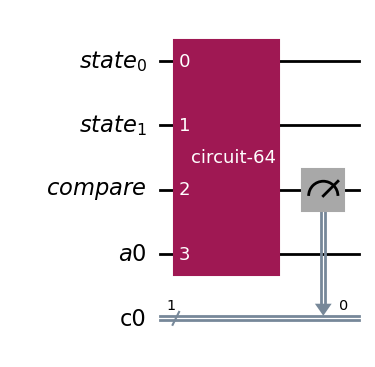

In [34]:
from qiskit.circuit.library import IntegerComparator

# Example 1: Integer Comparator as a Gate
# Compare if a 2-qubit number (0-3) is < 3 
qc = IntegerComparator(2, 3, geq=False)
qc.add_register(ClassicalRegister(1))
#Result is stored in the third qubit (flips if condition is true)
#Output is 0 < 3  => True , third qubit should be flipped
qc.measure(2,0)
print("Integer Comparator Circuit:")
qc.draw('mpl')

Weighted Adder Circuit:


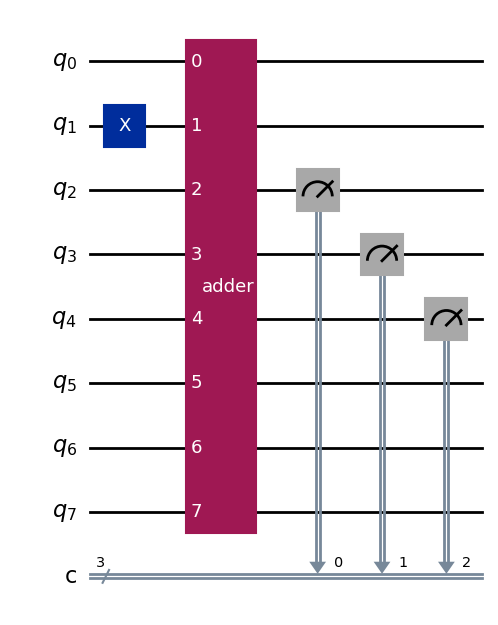

In [32]:
from qiskit.circuit.library import WeightedAdder

# Example 2: Weighted Adder as a Circuit
# Compute weighted sum: 2*x0 + 3*x1
weights = [2, 3]


weighted_adder = WeightedAdder(2, weights=weights)
qc = QuantumCircuit(weighted_adder.num_qubits, 3)
# setup input to represent x1=1 (qubit 1) and x0=0 (qubit 0)
qc.x(1)
# append the weighted adder circuit
qc.append(weighted_adder, range(weighted_adder.num_qubits))
#Output is stored in 3-qubit sum register in qubits 2,3,4
#Output is 3*1 + 2*0 = 3
qc.measure(range(2, 5), range(3))
print("Weighted Adder Circuit:")
qc.draw('mpl')

Measurement Output: {'011': 1000}


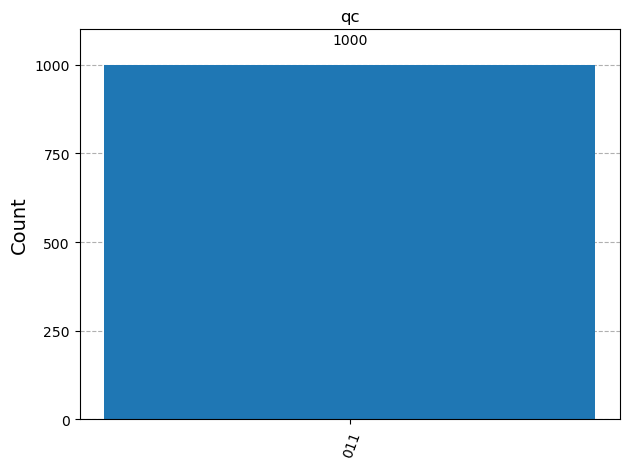

In [33]:
sim_ideal = AerSimulator()
result = sim_ideal.run(transpile(qc , sim_ideal),shots=1000).result()
counts = result.get_counts(0)
print("Measurement Output:", counts)
plot_histogram(counts, title='qc')

#### N-Local Circuits
N Local Circuits are parameterized quantum circuits that are used as ansatzes in variational quantum algorithms like VQE and QAOA. these functions exist in BlueprintCircuit and QuantumCircuit representations. BlueprintCircuit wraps the circuits into a block and allow for inplace mutations of the circuits , while QuantumCircuit are optimized for fast consturction.


**`QuantumCircuit` represenation**

- **n_local**:	An n-local variational circuit with alternating rotation and entanglement layers..
- **efficient_su2**:	Hardware-efficient SU(2) 2-local circuit used in variational algorithms and in classificaiton.
- **real_amplitudes**:	Construct a real-amplitudes 2-local circuit used as ansatz in chemistry, optimization or machine learning applications.
- **pauli_two_design**:	Construct a Pauli 2-design ansatz.
- **excitation_preserving**:	Heuristic excitation-preserving wave function ansatz.
- **qaoa_ansatz**:	A generalized QAOA quantum circuit with a support of custom initial states and mixers.
- **hamiltonian_variational_ansatz**:	Construct a Hamiltonian variational ansatz.
- **evolved_operator_ansatz**:	Construct an ansatz out of operator evolutions.

**`BlueprintCircuit` representation** 

- **NLocal**:	n-local `BlueprintCircuit`.
- **TwoLocal**:	two-local `BlueprintCircuit`.
- **PauliTwoDesign**: Pauli Two-Design ansatz `BlueprintCircuit`.
- **RealAmplitudes**: real-amplitudes 2-local `BlueprintCircuit`.
- **EfficientSU2**:	Hardware efficient SU(2) 2-local `BlueprintCircuit`.
- **EvolvedOperatorAnsatz**:	The evolved operator ansatz `BlueprintCircuit`.
- **ExcitationPreserving**:	Excitation-preserving ansatz `BlueprintCircuit` .
- **QAOAAnsatz**:	QAOA `BlueprintCircuit`.


RealAmplitudes Ansatz (3 qubits, pairwise entanglement):

Number of parameters: 9
Parameter names: ['θ[0]', 'θ[1]', 'θ[2]', 'θ[3]', 'θ[4]', 'θ[5]', 'θ[6]', 'θ[7]', 'θ[8]']


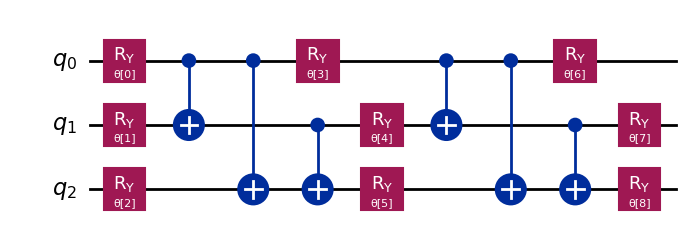

In [35]:
from qiskit.circuit.library import real_amplitudes, EfficientSU2

# Example 1: real_amplitudes ansatz
# Commonly used for quantum chemistry problems
ansatz = real_amplitudes(3, entanglement="full", reps=2)
print("\nRealAmplitudes Ansatz (3 qubits, pairwise entanglement):")
# Show the parameters
print(f"\nNumber of parameters: {ansatz.num_parameters}")
print(f"Parameter names: {[p.name for p in ansatz.parameters]}")
ansatz.draw('mpl')


C:\Users\nikhi\AppData\Local\Temp\ipykernel_39156\4265856534.py:4: DeprecationWarning: The class ``qiskit.circuit.library.n_local.efficient_su2.EfficientSU2`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. Use the function qiskit.circuit.library.efficient_su2 instead.
  efficient_ansatz = EfficientSU2(3, entanglement="full", reps=2)



EfficientSU2 Ansatz (3 qubits, full entanglement):


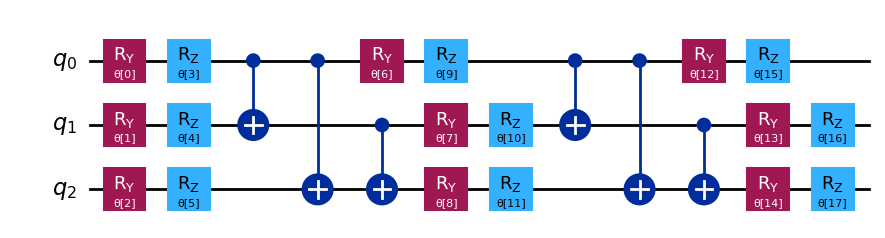

In [36]:
# Example 2: EfficientSU2 ansatz as BlueprintCircuit
# Hardware-efficient ansatz with SU(2) rotations
# use full entanglement and 2 repetitions
efficient_ansatz = EfficientSU2(3, entanglement="full", reps=2)
print("\nEfficientSU2 Ansatz (3 qubits, full entanglement):")
efficient_ansatz.decompose().draw('mpl')

#### Data Encoding Circuits

Data encoding circuits are used in encode classical data into quantum states for quantum machine learning.Similarly these functions exist in `BlueprintCircuit` and `QuantumCircuit` representations.

**`QuantumCircuit` representation** 

- **pauli_feature_map**: Pauli expansion circuit, it uses pauli gates to encode data.
- **z_feature_map**: First order Pauli Z-evolution circuit.subclass of `pauli_feature_map` where the pauli gates are 'Z' gates only 
- **zz_feature_map**: Second-order Pauli-Z evolution circuit.

**`BlueprintCircuit` representation** 

- **PauliFeatureMap**:	Pauli Expansion `BlueprintCircuit`.
- **ZFeatureMap**:	First order Pauli Z-evolution `BlueprintCircuit`.
- **ZZFeatureMap**:	Second-order Pauli-Z evolution `BlueprintCircuit`.



ZFeatureMap (3 qubits, 2 repetitions):


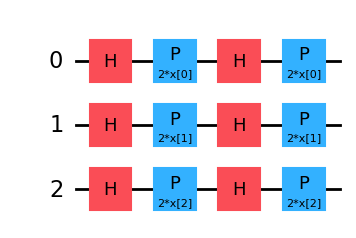

In [37]:
from qiskit.circuit.library import z_feature_map

# Example 1: PauliFeatureMap as BlueprintCircuit
z_map = z_feature_map(3, reps=2)
print("\nZFeatureMap (3 qubits, 2 repetitions):")
z_map.draw('mpl')

In [ ]:
from qiskit.circuit.library import PauliFeatureMap

# Example 1: PauliFeatureMap as BlueprintCircuit
p_map = PauliFeatureMap(3, reps=2, paulis=['ZZ', 'XX'])
print("\nPauliFeatureMap (3 qubits, 2 repetitions):")
p_map.decompose().draw('mpl')

#### Data Preparation Circuit


State Preparation Circuit for |ψ⟩ = (|00⟩ + |11⟩)/√2:


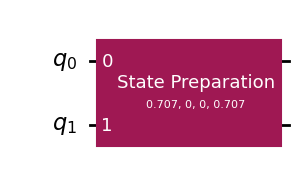

In [38]:
# Example: State Preparation Circuit
from qiskit.circuit.library import StatePreparation

# Prepare a specific 3-qubit state |ψ⟩ = (|00⟩ + |11⟩)/√2
# Define the target state amplitudes 00, 01, 10, 11
target_state = [1/np.sqrt(2), 0, 0, 1/np.sqrt(2)]
state_prep = StatePreparation(target_state)
print("\nState Preparation Circuit for |ψ⟩ = (|00⟩ + |11⟩)/√2:")
# use in circuit
qc = QuantumCircuit(state_prep.num_qubits)
qc.append(state_prep, range(state_prep.num_qubits))
qc.draw('mpl')

#### Oracles
black box operations on quantum circuits


Bit Flip Oracle for expression: (a | b | c)


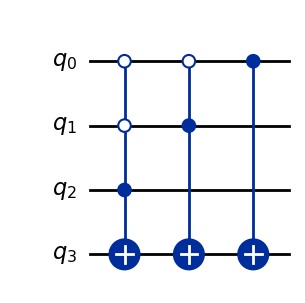

In [39]:
from qiskit.circuit.library import BitFlipOracleGate

# Example 1: BitFlip Oracle Gate
# Create an oracle that marks solutions to (a | b | c)

logical_expr = "(a | b | c)"
oracle = BitFlipOracleGate(logical_expr)
qc=QuantumCircuit(oracle.num_qubits)
qc.append(oracle, range(oracle.num_qubits))
print("\nBit Flip Oracle for expression:", logical_expr)
qc.decompose().draw('mpl')


Phase Oracle for expression: (a & b) | (c & d)


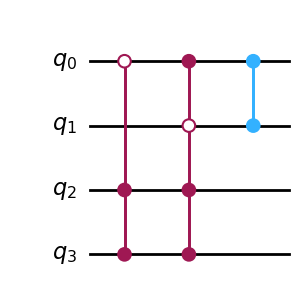

In [40]:
from qiskit.circuit.library import PhaseOracleGate

# Example 2: Phase Oracle for logical expressions
# Create an oracle that marks solutions to (a AND b) OR (c AND d)

logical_expr = "(a & b) | (c & d)"
oracle = PhaseOracleGate(logical_expr)
qc=QuantumCircuit(oracle.num_qubits)
qc.append(oracle, range(oracle.num_qubits))
print("\nPhase Oracle for expression:", logical_expr)
qc.decompose().draw('mpl')

### Template Circuits

Templates return circuits that compute the identity, and they are mainly used for circuit optimization. 


Template Verification:
template_nct_4b_1 is identity: True

Template Circuit (template_nct_4b_1):


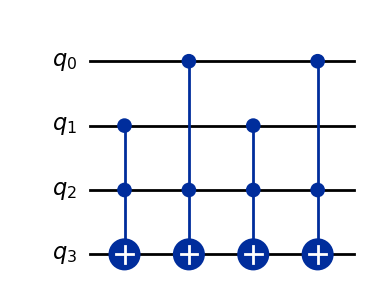

In [41]:
from qiskit.circuit.library.templates import template_nct_4b_1

# Example 1: template_nct_4b_1 verification
template = template_nct_4b_1()
identity = np.identity(2 ** len(template.qubits), dtype=complex)
data = Operator(template).data
is_identity = np.allclose(data, identity)

print("\nTemplate Verification:")
print(f"template_nct_4b_1 is identity: {is_identity}")

print("\nTemplate Circuit (template_nct_4b_1):")
template.draw('mpl')

# 4. Data Encoding Schemes (Feature Maps)

#### Basis Encoding
Suppose all features are stored in four bits like

5 → binary 0101

7 → binary 0111

0 → binary 0000

These bit strings are assigned to three sets of four qubits, so the overall 12-qubit basis state is: ∣0101 0111 0000⟩. Here, the first four qubits represent the first feature, the next four qubits the second feature, and the last four qubits the third feature. The code below converts the data vector (5,7,0) to a quantum state, and is generalized to do so for other single-digit features.

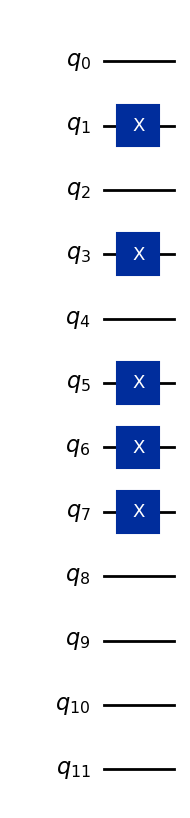

In [42]:
from qiskit import QuantumCircuit
 
# Data point to encode
x = 5  # binary: 0101
y = 7  # binary: 0111
z = 0  # binary: 0000
 
# Convert each to 4-bit binary list
x_bits = [int(b) for b in format(x, "04b")]  # [0,1,0,1]
y_bits = [int(b) for b in format(y, "04b")]  # [0,1,1,1]
z_bits = [int(b) for b in format(z, "04b")]  # [0,0,0,0]
 
# Combine all bits
all_bits = x_bits + y_bits + z_bits  # [0,1,0,1,0,1,1,1,0,0,0,0]
 
# Initialize a 12-qubit quantum circuit
qc = QuantumCircuit(12)
 
# Apply x-gates where the bit is 1
for idx, bit in enumerate(all_bits):
    if bit == 1:
        qc.x(idx)
 
qc.draw("mpl")


#### Amplitude Encoding
In amplitude encoding, each feature in a data vector is stored as an amplitude of a different quantum state. As an example, let's encode the first vector in our example dataset $\text{X}_\text{ex}$, $\vec{x}^{(1)} = (4,8,5)$ using amplitude encoding. Normalizing the resulting vector, we get:
$$
\sum_{i=1}^N \left|x^{(1)}_i\right|^2 = 4^2+8^2+5^2 = 105 = \left|\alpha\right|^2 \rightarrow \alpha = \sqrt{105}
$$
and the resulting 2-qubit quantum state would be:
$$
|\psi(\vec{x}^{(1)})\rangle = \frac{1}{\sqrt{105}}(4|00\rangle+8|01\rangle+5|10\rangle+0|11\rangle)
$$

In the example above, the number of features in the vector $N=3$, is not a power of 2. When $N$ is not a power of 2, we simply choose a value for the number of qubits $n$ such that $2^n\geq N$ and pad the amplitude vector with uninformative constants (here, a zero) so amplitude encoding of $N$ features requires $n \ge \mathrm{log}_2(N)$ qubits.

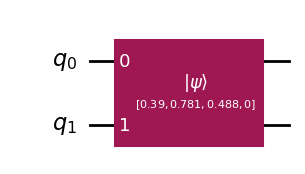

In [43]:
import math
 
desired_state = [
    1 / math.sqrt(105) * 4,
    1 / math.sqrt(105) * 8,
    1 / math.sqrt(105) * 5,
    1 / math.sqrt(105) * 0,
]
 
qc = QuantumCircuit(2)
qc.initialize(desired_state, [0, 1])
 
qc.draw(output="mpl")

#### Angle Encoding
In angle encoding:

*   Each feature value is mapped to a corresponding qubit, $\vec{x}^{(j)}_k \rightarrow Q_k$, leaving the qubits in a product state.
*   One numerical value is encoded at a time, rather than a whole set of features from a data point.
*   $n$ qubits are required for $N$ data features, where $n\leq N$. Often equality holds, here. We'll see how $n<N$ is possible in the next few sections.
*   The resulting circuit is a constant depth (typically the depth is 1 prior to transpilation).

The angle encoding can be implemented using any rotation gate. One additional feature of encoding our data using  Y-rotation is that it creates real-valued quantum states that can be useful for certain applications. The data has to be rescaled so that $\vec{x}^{(j)}_k \in (0,2\pi]$, preventing information loss and other unwanted effects.

The following Qiskit code rotates a single qubit from an initial state $|0\rangle$ to encode a data value $\vec{x}^{(j)}_k=\frac{1}{2}\pi$.

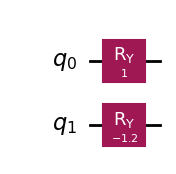

In [44]:
from qiskit.quantum_info import Statevector
from math import pi

qc = QuantumCircuit(2)
state1 = Statevector.from_instruction(qc)
qc.ry(1, 0)  
qc.ry(-1.2, 1)  
qc.draw("mpl")

That was just a single feature of a single data vector. When encoding $N$ features into the rotation angles of $n$ qubits, say for the $j^\text{th}$ data vector $\vec{x}^{(j)} = (x_1,...,x_N),$ the encoded product state will look like this:
$$
|\vec{x}^{(j)}\rangle = \bigotimes^N_{k=1} R_Y(2\vec{x}^{(j)}_k)|0\rangle= \bigotimes^N_{k=1} \cos(\vec{x}^{(j)}_k)|0\rangle + \sin(\vec{x}^{(j)}_k)|1\rangle
$$

#### Phase Encoding
The phase encoding procedure maps each feature value to the phase $\phi$ of a corresponding qubit, $\vec{x}^{(j)}_k \rightarrow Q_k$. In total, phase encoding has a circuit depth of 2, including the Hadamard layer, which makes it an efficient encoding scheme. The phase-encoded multi-qubit state ($n$ qubits for $N=n$ features) is a product state:
$$
|\vec{x}^{(j)}\rangle = \bigotimes_{k=1}^{N} P_k(\phi = \vec{x}^{(j)}_k)|+\rangle^{\otimes N} = {\textstyle\frac{1}{\sqrt{2^N}}} \bigotimes_{k=1}^{N}\big(|0\rangle + e^{i\vec{x}^{(j)}_k}|1\rangle\big).
$$

The following Qiskit code first prepares the initial state of a single qubit by rotating it with a Hadamard gate, then phase-ecodes the data point $\vec{x}^{(j)}_k=\frac{1}{2}\pi$ using a phase gate.


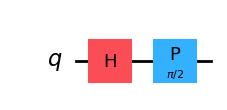

In [45]:
from qiskit.quantum_info import Statevector
from math import pi
qc = QuantumCircuit(1)
qc.h(0)  # Hadamard gate rotates state down to Bloch equator
state1 = Statevector.from_instruction(qc)

qc.p(pi / 2, 0)  # Phase gate rotates by an angle pi/2
state2 = Statevector.from_instruction(qc)

states = state1, state2

qc.draw("mpl", scale=1)

#### Dense angle encoding

Dense angle encoding (DAE) is a combination of angle encoding and phase encoding. DAE allows two feature values to be encoded in a single qubit: $\theta$ with a Y-axis rotation , and $\phi$ with a $z$-axis rotation. Encoding two data features to one qubit results in a $2$-times reduction in the number of qubits required for the encoding. Extending this to more features, the data vector $\vec{x} = (x_1,...,x_N)$ can be encoded as:

$$
|\vec{x}\rangle = \bigotimes_{k=1}^{N/2} \cos(\frac{x_{2k-1}}{2})|0\rangle + e^{i x_{2k}}\sin(\frac{x_{2k-1}}{2})|1\rangle
$$

DAE can be generalized to arbitrary functions of the two features instead of the sinusoidal functions used here. This is called general qubit encoding.

As an example of DAE, the code below encodes and visualizes the encoding of the features $x_1=\theta = 3\pi/8$ and $x_2=\phi = 7\pi/4$.

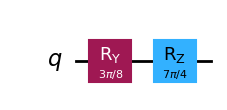

In [46]:
qc = QuantumCircuit(1)
state1 = Statevector.from_instruction(qc)
qc.ry(3 * pi / 8, 0)
state2 = Statevector.from_instruction(qc)
qc.rz(7 * pi / 4, 0)
state3 = Statevector.from_instruction(qc)
states = state1, state2, state3

qc.draw("mpl", scale=1)

#### Efficient SU2
Since amplitudes in a statevector are complex numbers, a single qubit state has four real parameters (though constrained by the requirement of normalization), a two qubit state has eight real parameters, and so on. The Efficient SU2 scheme can encode many more data points with fewer qubits. For example, a two qubit state with a single repetition is
$$
\begin{align}
\nonumber
|\psi\rangle_{\text{final}} &= \cos(\theta_0/2)
\left(\cos(\theta_4/2)|0\rangle+\sin(\theta_4/2)e^{i\theta_6}|1\rangle\right)\\ \nonumber
&\otimes \left[ \cos(\theta_1/2)
    \left( \cos(\theta_5/2)|0\rangle+\sin(\theta_5/2)e^{i \theta_7}|1\rangle\right)
+\sin(\theta_1/2)e^{i\theta_3}\left(-\sin(\theta_5/2)|0\rangle+\cos(\theta_5/2)e^{i \theta_7}|1\rangle\right)
    \right]\\ \nonumber
&+\sin(\theta_0/2)e^{i\theta_2}
\left(-\sin(\theta_4/2)|0\rangle+\cos(\theta_4/2)e^{i\theta_6}|1\rangle\right)\\ \nonumber
&\otimes \left[
\sin(\theta_1/2)e^{i\theta_3}\left(\cos(\theta_5/2)|0\rangle+\sin(\theta_5/2)e^{i \theta_7}|1\rangle\right)
+\cos(\theta_1/2)e^{i\theta_3}\left(-\sin(\theta_5/2)|0\rangle+\cos(\theta_5/2)e^{i \theta_7}|1\rangle\right)
\right]
\end{align}
$$

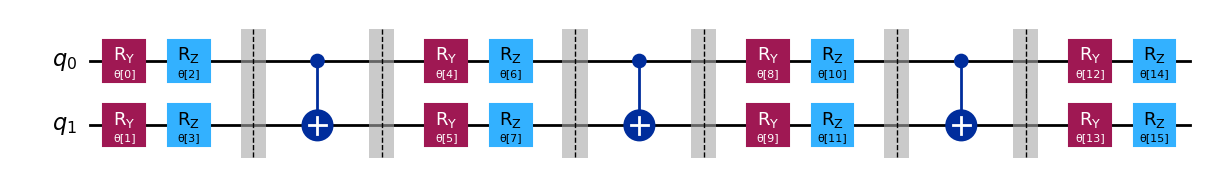

In [47]:
from qiskit.circuit.library import efficient_su2

circuit = efficient_su2(num_qubits=2, reps=3, insert_barriers=True)
circuit.draw(output="mpl")

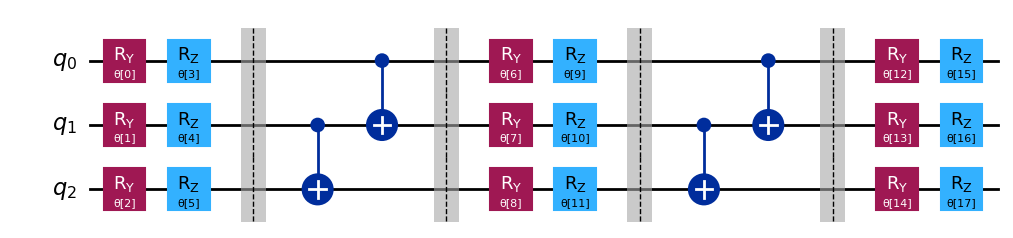

In [48]:
from qiskit.circuit.library import efficient_su2

circuit = efficient_su2(num_qubits=3, reps=2, insert_barriers=True)
circuit.draw(output="mpl")

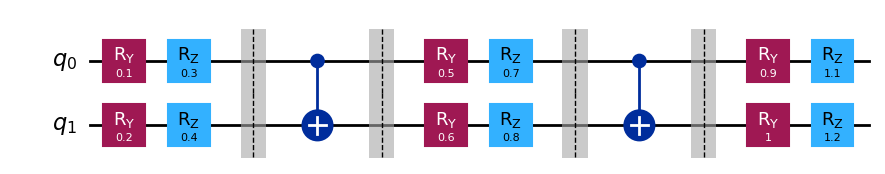

In [49]:
x = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0, 1.1, 1.2]
from qiskit.circuit.library import efficient_su2

circuit = efficient_su2(num_qubits=2, reps=2, insert_barriers=True)
encode = circuit.assign_parameters(x)
encode.draw(output="mpl")

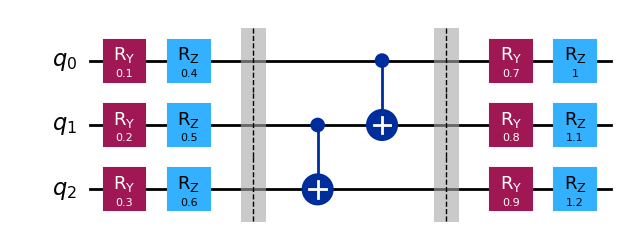

In [50]:
x = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0, 1.1, 1.2]
circuit = efficient_su2(num_qubits=3, reps=1, insert_barriers=True)
encode = circuit.assign_parameters(x)
encode.draw(output="mpl")

#### Z Feature Map
The $Z$ feature map (ZFM) can be interpreted as a natural extension of phase encoding. The ZFM consists of alternating layers  of Hadamard gates and and phase gates. Let the data vector $\vec{x}$ have $N$ features.  The data features $x_i$ are mapped one-to-one with corresponding qubits.  The full ZFM circuit unitary with a single repetition is:

$$
\mathscr{U}_{\text{ZFM}}=\big(P(\vec{x}_1)\otimes\ldots P(\vec{x}_k)\otimes\ldots P(\vec{x}_N)H^{\otimes N}\big)=\left(\bigotimes_{k = 1}^N P(\vec{x}_k)\right)H^{\otimes N}
$$

Then $r$ repetitions of this unitary would be

$$
\mathscr{U}^{(r)}_{\text{ZFM}}\left(\vec{x}\right)=\prod_{s=1}^{r}\left[\left(\bigotimes_{k = 1}^N P(\vec{x}_k)\right)H^{\otimes N}\right]
$$

The data features, $x_k$, are mapped to the phase gates in the same way in all $r$ repetitions. 

 The following Qiskit code uses Hadamard and phase gates explicitly to show the structure of the ZFM:

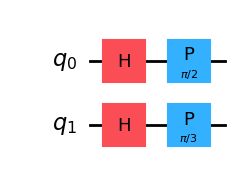

In [51]:
qc0 = QuantumCircuit(1)
qc1 = QuantumCircuit(1)

qc0.h(0)
qc0.p(pi / 2, 0)

qc1.h(0)
qc1.p(pi / 3, 0)

# Combine circuits qc0 and qc1 into 1 circuit
qc = QuantumCircuit(2)
qc.compose(qc0, [0], inplace=True)
qc.compose(qc1, [1], inplace=True)

qc.draw("mpl", scale=1)

#### ZZ Feature Map
The $ZZ$ feature map (ZZFM) extends the ZFM with the inclusion of two-qubit entangling gates, specifically the $ZZ$-rotation gate $R_{ZZ}(\theta)$. The ZZFM is conjectured to be generally expensive to compute on a classical computer, unlike the ZFM.

A single repetition of the ZZFM circuit is:

$$
\mathscr{U}_{\text{ZZFM}}(\vec{x}) = R_{ZZ,q,p}(\theta_{q,p})(\vec{x})\left(\bigotimes_{k = 1}^N P(\vec{x}_k)\right)H^{\otimes N},
$$

 Entanglemt schemes can be linear, circular, full etc.  In the phase layer, the qubits p and q have phase gates that encode $\vec{x}_p$ and $\vec{x}_q$ on them, respectively. By default
$$
\theta_{q,p} \rightarrow \phi(\vec{x}_q, \vec{x}_p) = 2(\pi-\vec{x}_q)(\pi-\vec{x}_p).
$$
but we can define our own $\phi$ as well. Also, $R_{ZZ}$ can be replaced by another multi-qubit unitary.


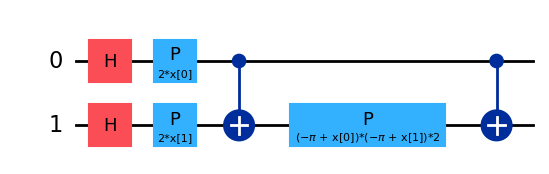

In [52]:
from qiskit.circuit.library import zz_feature_map

feature_dim = 2
zzfeature_map = zz_feature_map(
    feature_dimension=feature_dim, entanglement="linear", reps=1
)
zzfeature_map.draw("mpl", scale=1)

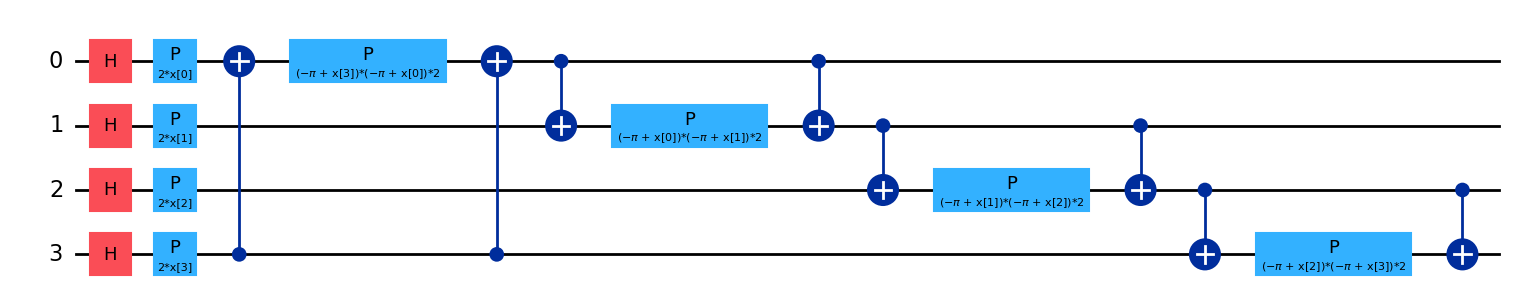

In [53]:
feature_dim = 4
zzfeature_map = zz_feature_map(
    feature_dimension=feature_dim, entanglement="circular", reps=1
)
zzfeature_map.draw("mpl", scale=1)

#### Pauli feature map

The Pauli feature map (PFM) is the generalization of the ZFM and ZZFM to use arbitrary Pauli gates. The Pauli feature map takes a very similar form to the previous two feature maps. For $r$ repetitions of the encoding of the $N$ features of vector $\vec{x},$

$$
\mathscr{U}_{\text{PFM}}(\vec{x}) = \prod_{s=1}^{r} U(\vec{x}) H^{\otimes n}.
$$

For PFM, $U(\vec{x})$ is generalized to a Pauli expansion unitary operator. Here we present a more generalized form of the feature maps considered so far:

$$
U(\bar{x}) = \exp\left(i \alpha \sum_{S\subseteq[n]} \phi_S(\bar{x}) \prod_{i \in S} \sigma_i \right)
$$

where $\sigma_i$ is a Pauli operator, $\sigma_i \in {I,X,Y,Z}$. Here $\mathcal{I}$ is the set of all qubit connectivities as determined by the feature map, including the set of qubits acted on by single-qubit gates. And

$$
\phi_S(\vec{x})=
    \begin{cases}
      x_i & \text{if } S= \{i\} \text{ (single-qubit)}\\
      \prod_{j\in{S}}(\pi-x_j) & \text{if } |S|\ge2 \text{ (multi-qubit)}\\
    \end{cases}
$$


The default value of $\alpha$ is $2$. By optimizing its value in the interval, for example, $[0,4],$ one can better align a quantum kernel to the data.

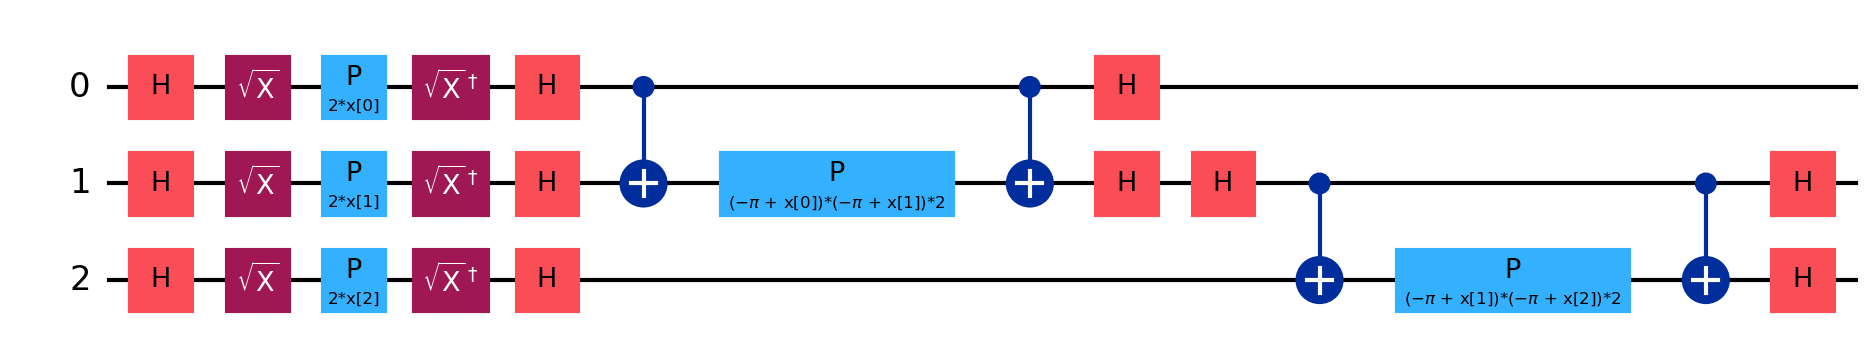

In [54]:
from qiskit.circuit.library import pauli_feature_map
 
feature_dim = 3
pfmap = pauli_feature_map(
    feature_dimension=feature_dim, entanglement="linear", reps=1, paulis=["Y", "XX"]
)
 
pfmap.draw("mpl", scale=1.5)

#### Two Local
It creates parameterized circuits of alternating rotation and entanglement layers. In both layers, parameterized circuit-blocks act on the circuit in a defined way. In the rotation layer, the blocks are applied stacked on top of each other, while in the entanglement layer according to the entanglement strategy. Each layer is repeated a number of times, and by default a final rotation layer is appended.


C:\Users\nikhi\AppData\Local\Temp\ipykernel_39156\4282920205.py:3: DeprecationWarning: The class ``qiskit.circuit.library.n_local.two_local.TwoLocal`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. Use the function qiskit.circuit.library.n_local instead.
  twolocal = TwoLocal(num_qubits=5, reps=1, rotation_blocks=['ry','rz'],


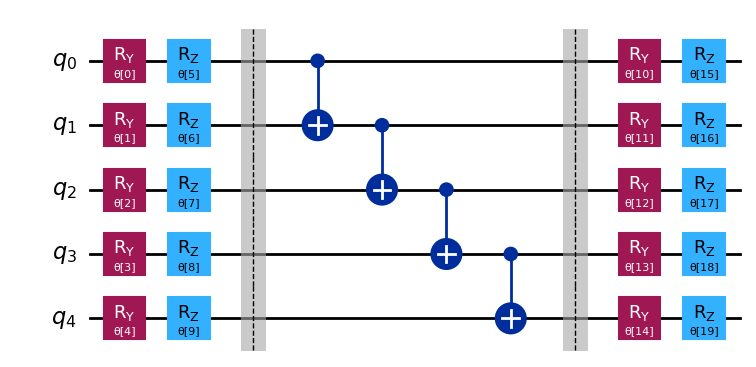

In [55]:
from qiskit.circuit.library import TwoLocal

twolocal = TwoLocal(num_qubits=5, reps=1, rotation_blocks=['ry','rz'], 
               entanglement_blocks='cx', entanglement='linear', insert_barriers=True)
twolocal.decompose().draw('mpl')

#### NLocal
In NLocal, the circuit blocks can have arbitrary sizes (smaller equal to the number of qubits in the circuit), while in TwoLocal, the rotation layers are single qubit gates applied on all qubits and the entanglement layer uses two-qubit gates.

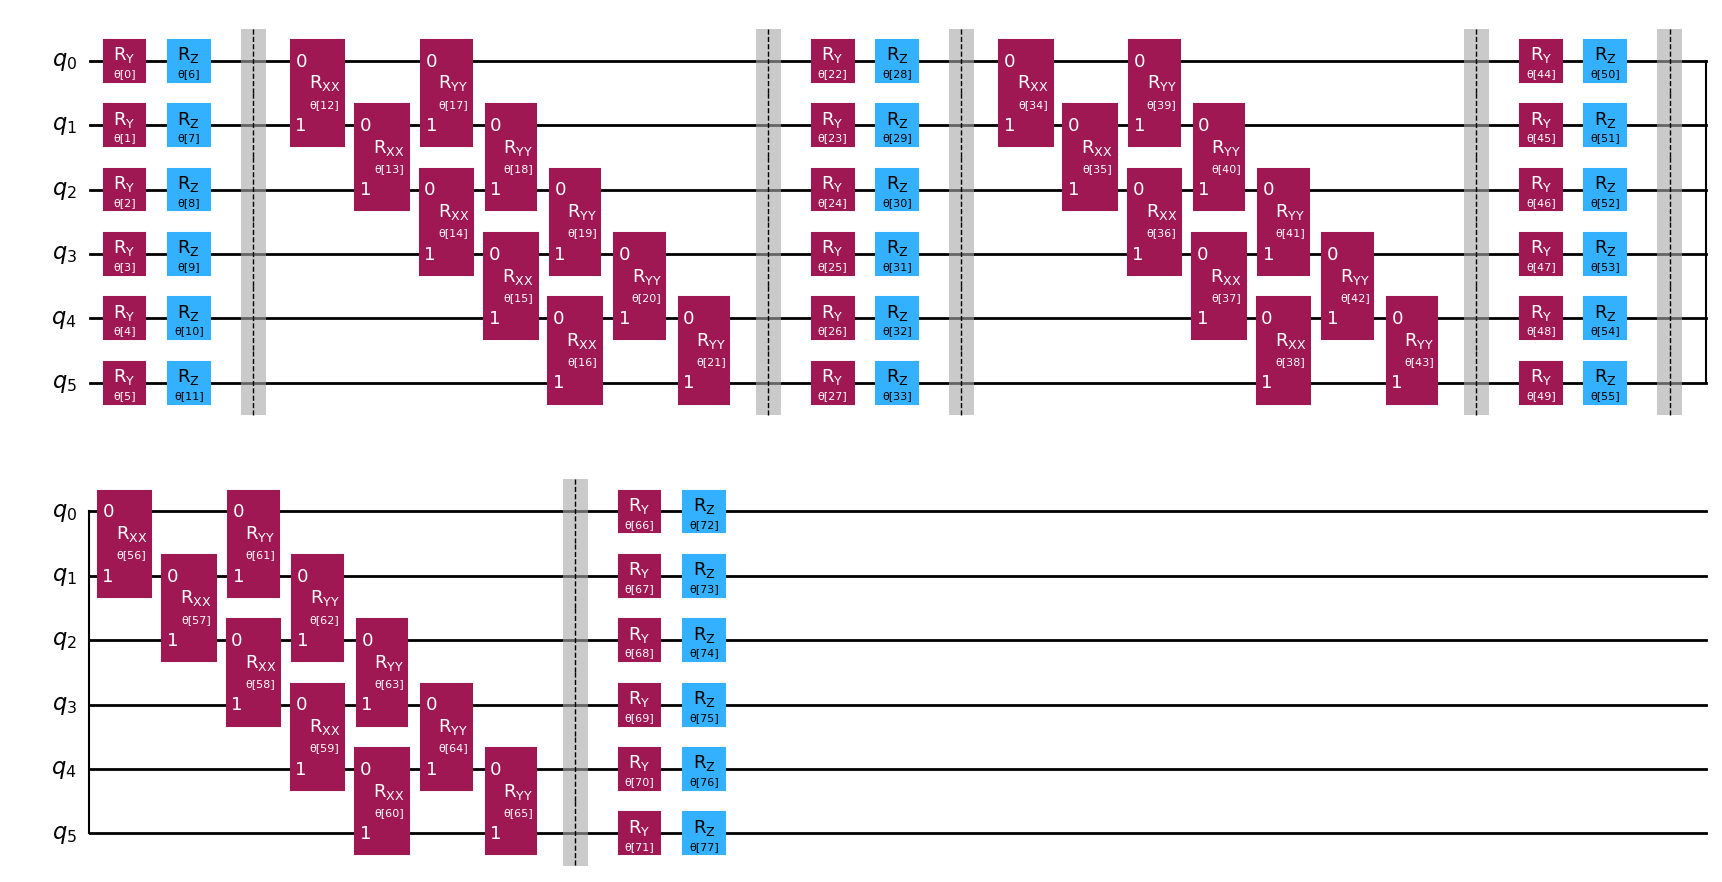

In [56]:
from qiskit.circuit import QuantumCircuit, ParameterVector
from qiskit.circuit.library.n_local import n_local
# rotation block:


nlocal = n_local(6, rotation_blocks=['ry','rz'], entanglement_blocks=['rxx','ryy'], 
                entanglement='linear', insert_barriers=True)
nlocal.draw('mpl')

# 5. Quantum Circuit Mechanics

In [57]:
import warnings
# Filter the specific warning from Qiskit about Cregbundle
warnings.filterwarnings('ignore', message='.*Cregbundle set to False.*', category=RuntimeWarning)
import numpy as np
import matplotlib.pyplot as plt
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister
from qiskit.circuit import Qubit, Clbit, BoxOp
from qiskit.visualization import plot_histogram, plot_state_qsphere, plot_state_city
from qiskit.quantum_info import Statevector
from qiskit_aer import AerSimulator
from qiskit.transpiler import generate_preset_pass_manager
from qiskit.circuit.library import XGate
import qiskit.circuit.library as library


# Try to import GenericBackendV2, handling different Qiskit versions
try:
    from qiskit.providers.fake_provider import GenericBackendV2
except ImportError:
    try:
        from qiskit_ibm_runtime.fake_provider import GenericBackendV2
    except ImportError:
        GenericBackendV2 = None
        print("Warning: GenericBackendV2 not found. Transpilation examples might skip.")


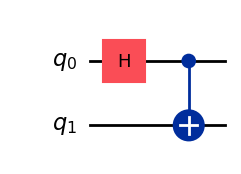

In [58]:
from qiskit import QuantumCircuit

# Create a new circuit with two qubits
qc = QuantumCircuit(2)
 
# Add a Hadamard gate to qubit 0
qc.h(0)
 
# Perform a controlled-X gate on qubit 1, controlled by qubit 0
qc.cx(0, 1)
 
# Return a text drawing of the circuit.
qc.draw('mpl')

#### Attribute

In [59]:
# The data attribute provides direct access to the list of instructions that make up the circuit. 
# Each item in the list is a `CircuitInstruction` object containing the operation and the qubits/clbits it applies to.
print(qc.data)

# The global_phase attribute tracks the global phase of the circuit in radians. 
# While global phase does not affect measurement probabilities, it is crucial when controlling the circuit or combining it with others.
print(qc.global_phase)

# One can access the quantum (`qregs`) and classical (`cregs`) registers associated with the circuit. 
# This is useful for inspecting the circuit's structure.
print(qc.qregs)
print(qc.cregs)

# The layout attribute (typically populated after transpilation) shows how the virtual qubits in your circuit map to the physical qubits on a device.
from qiskit import QuantumCircuit
from qiskit.providers.fake_provider import GenericBackendV2
from qiskit.transpiler import generate_preset_pass_manager
 
# Create circuit to test transpiler on
qc = QuantumCircuit(3, 3)
qc.h(0)
qc.cx(0, 1)
qc.swap(1, 2)
qc.cx(0, 1)
 
# Add measurements to the circuit
qc.measure([0, 1, 2], [0, 1, 2])
 
# Specify the QPU to target
backend = GenericBackendV2(3)
 
# Transpile the circuit
pass_manager = generate_preset_pass_manager(
optimization_level=1, backend=backend
)
transpiled = pass_manager.run(qc)
 
# Print the layout after transpilation
print(transpiled.layout.routing_permutation())

[CircuitInstruction(operation=Instruction(name='h', num_qubits=1, num_clbits=0, params=[]), qubits=(<Qubit register=(2, "q"), index=0>,), clbits=()), CircuitInstruction(operation=Instruction(name='cx', num_qubits=2, num_clbits=0, params=[]), qubits=(<Qubit register=(2, "q"), index=0>, <Qubit register=(2, "q"), index=1>), clbits=())]
0.0
[QuantumRegister(2, 'q')]
[]
[0, 1, 2]


#### Circuit Construction Methods

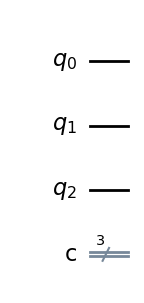

In [60]:
qc2 = qc.copy_empty_like()
qc2.draw('mpl')

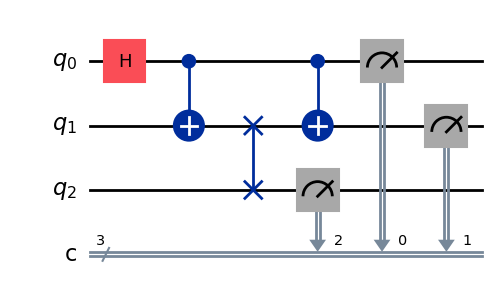

In [61]:
qc_copy = qc.copy()
# Modify copy to show independence
qc_copy.x(0)
qc.draw('mpl')

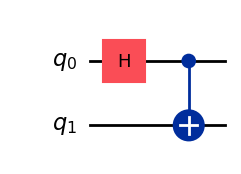

In [62]:
# from_qasm_str - Imports a circuit that is defined in OpenQASM 2.0 string format.
qasm_str = """OPENQASM 2.0;
include "qelib1.inc";
qreg q[2];
h q[0];
cx q[0],q[1];"""
qc = QuantumCircuit.from_qasm_str(qasm_str)
qc.draw('mpl')

#### Data Objects

Methods for managing the wires (qubits and classical bits) and variables in the circuit.

In [63]:
from qiskit.circuit import QuantumCircuit
 
qc = QuantumCircuit(2)
my_var = qc.add_var("my_var", False)

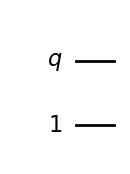

In [ ]:
# add_bits

from qiskit.circuit import Qubit
qc = QuantumCircuit(1)
new_bit = Qubit()
qc.add_bits([new_bit])
qc.draw('mpl')


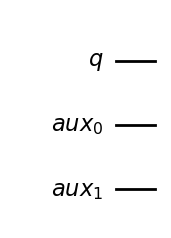

In [67]:
# add_register

from qiskit import QuantumRegister
qc = QuantumCircuit(1)
qr = QuantumRegister(2, 'aux')
qc.add_register(qr)
qc.draw('mpl')

In [ ]:
# add_input (feature for dynamic circuits where inputs might be provided at runtime.)

from qiskit import QuantumCircuit
import qiskit
from qiskit.circuit.classical import types

qc = QuantumCircuit(1)

# Preferred usage: pass an instance from qiskit.circuit.classical.types
# Older code sometimes used a deprecated `dtype` keyword or different signatures,
# so we attempt the modern call and provide a fallback with an explanatory note.
try:
    # Add a boolean input variable named 'x' (modern API)
    x_var = qc.add_input("x", types.Bool())
    print("Successfully added input variable:", x_var)
except TypeError:
    try:
        # Some Qiskit versions accept the type class itself as a fallback
        x_var = qc.add_input("x", types.Bool)
        print("Successfully added input variable (fallback):", x_var)
    except Exception as e:
        print("Error adding input variable (see note above):", e)

# Note: if you previously saw errors, that was likely due to a deprecated/changed
# add_input signature in older Qiskit versions. The approach above attempts
# the modern call first and falls back if needed.

Successfully added input variable: Var(UUID('80473ed0-b120-4c42-a6af-b54b10feb7cc'), Bool(), name='x')


#### Working with Bits

Qiskit provides tools to seamlessly convert between integer indices and bit instances.

In [69]:
from qiskit.circuit import QuantumCircuit, Qubit
 
qc = QuantumCircuit(3, 3)
qc.h(0)
qc.cx(0, 1)
qc.cx(1, 2)
qc.measure([0, 1, 2], [0, 1, 2])
 
# The `.qubits` and `.clbits` fields are not integers.
assert isinstance(qc.data[0].qubits[0], Qubit)
# ... but we can use `find_bit` to retrieve them.
assert qc.find_bit(qc.data[0].qubits[0]).index == 0
 
simple = [
    (
        instruction.operation.name,
        [qc.find_bit(bit).index for bit in instruction.qubits],
        [qc.find_bit(bit).index for bit in instruction.clbits],
    )
    for instruction in qc.data
]

#### Adding Operations

Methods to add instructions and combine circuits.
This includes operations that change the circuit structure; for example, `tensor` composes systems into a larger Hilbert space — i.e., it is equivalent to creating a larger system whose state space is the tensor product of the operand systems.

In [70]:
qc2.x(0)
qc.tensor(qc2).draw()

┌───┐                   
q_0: ┤ X ├───────────────────
     └───┘                   
q_1: ────────────────────────
                             
q_2: ────────────────────────
     ┌───┐          ┌─┐      
q_3: ┤ H ├──■───────┤M├──────
     └───┘┌─┴─┐     └╥┘┌─┐   
q_4: ─────┤ X ├──■───╫─┤M├───
          └───┘┌─┴─┐ ║ └╥┘┌─┐
q_5: ──────────┤ X ├─╫──╫─┤M├
               └───┘ ║  ║ └╥┘
c: 6/════════════════╩══╩══╩═
                     3  4  5

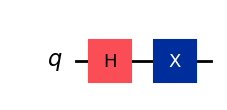

In [71]:
# append

from qiskit.circuit.library import XGate
qc = QuantumCircuit(1)
qc.h(0)
# Append an X gate
qc.append(XGate(), [0])
qc.draw('mpl')

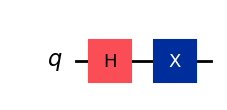

In [72]:
# compose
# Unlike append, compose flattens the other circuit into this one, rather than adding it as a single opaque instruction.

qc1 = QuantumCircuit(1)
qc1.h(0)
qc2 = QuantumCircuit(1)
qc2.x(0)
# Compose qc2 onto qc1
qc = qc1.compose(qc2, [0])
qc.draw('mpl')

`compose()` flattens the second circuit into the first so its gates appear inline. `append()` adds the other circuit as a single opaque instruction (a boxed gate) — visually you'll see one case expanded and the other as a single box. The example below shows `append()` on the same small circuits so you can compare the two drawings.

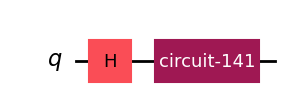

In [73]:
# Demonstrate append() so it appears as an opaque instruction
qc1 = QuantumCircuit(1)
qc1.h(0)
qc2 = QuantumCircuit(1)
qc2.x(0)
# Make a copy so we don't mutate the previous example
qc_app = qc1.copy()
# Convert qc2 into a single gate/instruction and append it
qc_app.append(qc2.to_gate(), [0])
qc_app.draw('mpl')

#### Standard Instructions

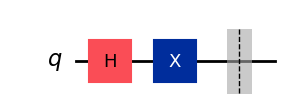

In [74]:
qc.barrier()

qc.draw('mpl')

Apply a delay (idle time) to a qubit. This is used in scheduling and noise characterization tasks. Delays represent idle/waiting time for qubits — they model scheduling pauses and exposure to decoherence, so they are useful when reasoning about timing and noise in experiments.

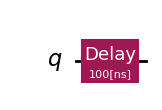

In [75]:
qc = QuantumCircuit(1)
qc.delay(100, 0, unit='ns')
qc.draw('mpl')

Initialize qubits to a specific state (e.g., from a statevector). Note that this is not a unitary operation in general and involves reset/prep.

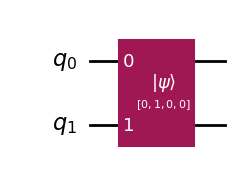

In [76]:
qc = QuantumCircuit(2)
qc.initialize([0, 1, 0, 0], [0, 1]) # Initialize to |01>
qc.draw('mpl')

Reset a qubit to the |0> state mid-circuit. This is a non-unitary dynamic operation.

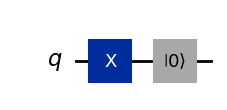

In [78]:
qc = QuantumCircuit(1)
qc.x(0)
qc.reset(0)
qc.draw('mpl')


Store a classical value into a classical bit. This is part of Qiskit's dynamic circuit capabilities.

Successfully added a 'store' instruction to the circuit.


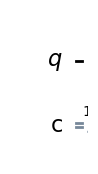


--- Environment Info ---
qiskit version: 2.3.1
Last instruction in circuit data: CircuitInstruction(operation=Instruction(name='store', num_qubits=0, num_clbits=0, params=[Var(<Clbit register=(1, "c"), index=0>, Bool()), Cast(Value(1, Uint(8)), Bool(), implicit=True)]), qubits=(), clbits=())


In [79]:
# Import the necessary components from Qiskit
import qiskit
from qiskit import QuantumCircuit
from qiskit.circuit.classical import types, expr

# --- The Correct Way to use qc.store in Modern Qiskit ---

# 1. Create a circuit with classical bits
qc = QuantumCircuit(1, 1)
target_clbit = qc.clbits[0]

# 2. Define the classical value you want to store.
# We use expr.lift() to create a classical literal from a Python value and a Qiskit type.
# For example, let's store the integer value 1 into an 8-bit unsigned integer type.
uint_value_to_store = expr.lift(1, types.Uint(8))

# 3. Use the store instruction within a try...except block for safety
try:
    qc.store(target_clbit, uint_value_to_store)
    print("Successfully added a 'store' instruction to the circuit.")
    # Draw the circuit to see the 'Store' instruction
    display(qc.draw('mpl'))
except Exception as e:
    print(f"The 'store' instruction failed: {e}")

# --- Environment Info ---
print("\n--- Environment Info ---")
# The correct way to get the version in modern Qiskit
print('qiskit version:', qiskit.__version__)

# Inspect the circuit data to confirm the instruction was added
if qc.data:
    print('Last instruction in circuit data:', qc.data[-1])
else:
    print('No instructions in the circuit.')

#### Uncontrolled Unitary Gates

Standard single and multi-qubit gates that do not have control conditions (e.g., X, H, Swap).

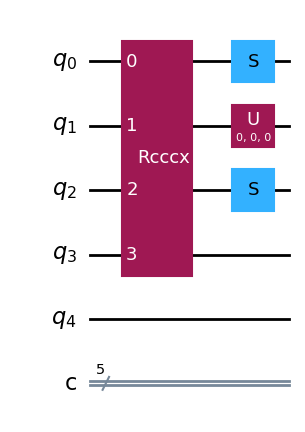

In [80]:
qc = QuantumCircuit(5,5)

qc.rcccx(0,1,2,3)
qc.s([0,2])
qc.u(0,0,0,1)

qc.draw('mpl')

#### Controlled Unitary Gates

Gates that are activated based on the state of control qubits (e.g., CX, CCX, CRZ).

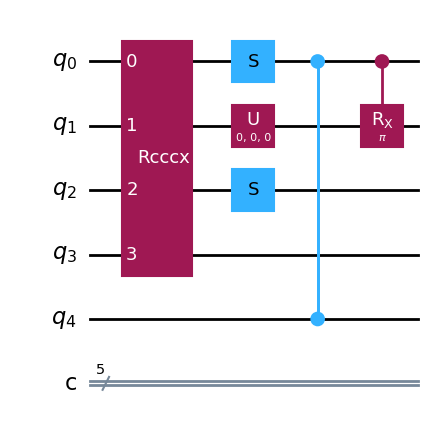

In [ ]:
qc.cz(0,4)
qc.crx(np.pi,0,1)

qc.draw('mpl')

#### Multiply Controlled Gates

Gates with multiple control lines, offering complex conditional logic.

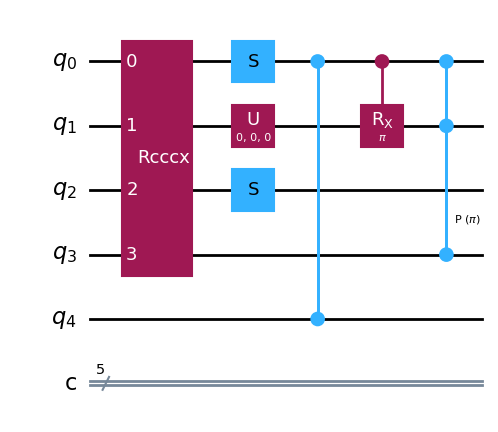

In [82]:
qc.mcp(np.pi,[0,1],3)

qc.draw('mpl')

#### Control Flow (Dynamic Circuits)

These operations enable dynamic circuits that can change their behavior based on mid-circuit measurement results.

In [83]:
from qiskit.circuit import QuantumCircuit, BoxOp
 
body_0 = QuantumCircuit(4)
body_0.cz(0, 1)
body_0.cz(2, 3)
 
# Note that the qubit indices inside a body related only to the body.  The
# association with qubits in the containing circuit is made by the ``qubits``
# argument to `QuantumCircuit.box`.
body_1 = QuantumCircuit(5)
body_1.cz(0, 1)
body_1.cz(2, 3)
 
qc = QuantumCircuit(9)
qc.box(body_0, [0, 1, 2, 3], [])
qc.box(body_1, [4, 5, 6, 7, 8], [])

qc.draw()

┌───────     ───────┐                      
q_0: ┤        ─■─        ├──────────────────────
     │         │         │                      
q_1: ┤        ─■─        ├──────────────────────
     │ Box-0       End-0 │                      
q_2: ┤        ─■─        ├──────────────────────
     │         │         │                      
q_3: ┤        ─■─        ├──────────────────────
     └───────     ───────┘┌───────     ───────┐ 
q_4: ─────────────────────┤        ─■─        ├─
                          │         │         │ 
q_5: ─────────────────────┤        ─■─        ├─
                          │                   │ 
q_6: ─────────────────────┤ Box-0  ─■─  End-0 ├─
                          │         │         │ 
q_7: ─────────────────────┤        ─■─        ├─
                          │                   │ 
q_8: ─────────────────────┤        ───        ├─
                          └───────     ───────┘

In [84]:
from qiskit.circuit import QuantumCircuit
 
 
qc = QuantumCircuit(9)
with qc.box():
    qc.cz(0, 1)
    qc.cz(2, 3)
with qc.box():
    qc.cz(4, 5)
    qc.cz(6, 7)
    qc.noop(8)

qc.draw()

┌───────     ───────┐                      
q_0: ┤        ─■─        ├──────────────────────
     │         │         │                      
q_1: ┤        ─■─        ├──────────────────────
     │ Box-0       End-0 │                      
q_2: ┤        ─■─        ├──────────────────────
     │         │         │                      
q_3: ┤        ─■─        ├──────────────────────
     └───────     ───────┘┌───────     ───────┐ 
q_4: ─────────────────────┤        ─■─        ├─
                          │         │         │ 
q_5: ─────────────────────┤        ─■─        ├─
                          │                   │ 
q_6: ─────────────────────┤ Box-0  ─■─  End-0 ├─
                          │         │         │ 
q_7: ─────────────────────┤        ─■─        ├─
                          │                   │ 
q_8: ─────────────────────┤        ───        ├─
                          └───────     ───────┘

In [85]:
import warnings
from qiskit import QuantumCircuit
qc = QuantumCircuit(2, 1)
 
with qc.for_loop(range(5)) as i:
    qc.x(0)
    qc.cx(0, 1)
    qc.measure(0, 0)
    with qc.if_test((0, True)):
        qc.break_loop()

with warnings.catch_warnings():
    warnings.simplefilter('ignore')
    qc.draw()

In [86]:
from qiskit.circuit import QuantumCircuit
 
qc = QuantumCircuit(3)
with qc.box():
    # This control-flow block will only use qubits 0 and 1.
    qc.cx(0, 1)
with qc.box():
    # This control-flow block will contain only the same operation as the previous
    # block, but it will also mark qubit 2 as "used" by the box.
    qc.cx(0, 1)
    qc.noop(2)

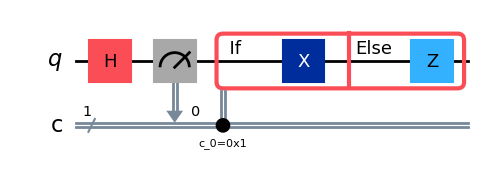

In [87]:
import warnings
# Suppress specific Qiskit warning about Cregbundle
warnings.filterwarnings('ignore', message='.*Cregbundle.*')
qc = QuantumCircuit(1, 1)
qc.h(0)
qc.measure(0, 0)
with qc.if_test((0, 1)) as else_block:
    qc.x(0)
with else_block:
    qc.z(0)
qc.draw('mpl')

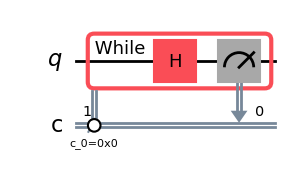

In [88]:
import warnings
# Suppress specific Qiskit warning about Cregbundle
warnings.filterwarnings('ignore', message='.*Cregbundle.*')
qc = QuantumCircuit(1, 1)
with qc.while_loop((0, 0)):
    qc.h(0)
    qc.measure(0, 0)
qc.draw('mpl')

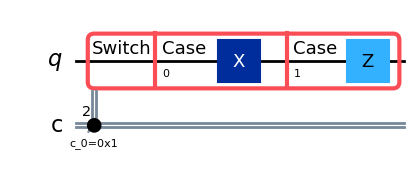

In [89]:
import warnings
# Suppress specific Qiskit warning about Cregbundle
warnings.filterwarnings('ignore', message='.*Cregbundle.*')
qc = QuantumCircuit(1, 2)
with qc.switch(0) as case:
    with case(0):
        qc.x(0)
    with case(1):
        qc.z(0)
qc.draw('mpl')

#### continue_loop

Skips the rest of the current iteration and jumps to the next iteration of the nearest enclosing loop.

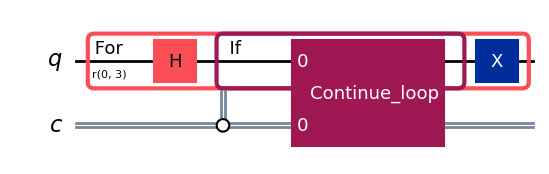

In [90]:
import warnings
# Suppress specific Qiskit warning about Cregbundle
warnings.filterwarnings('ignore', message='.*Cregbundle.*')
qc = QuantumCircuit(1, 1)
with qc.for_loop(range(3)):
    qc.h(0)
    with qc.if_test((0, 0)):
        qc.continue_loop()
    qc.x(0)
qc.draw('mpl')

#### Converters

Methods to package a circuit into a single `Instruction` or `Gate` object for reuse.

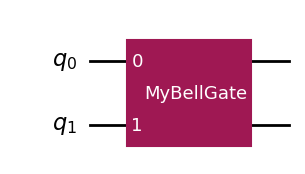

In [91]:
# Create a circuit without measurements for to_gate
qc_gate = QuantumCircuit(2)
qc_gate.h(0)
qc_gate.cx(0, 1)

# Convert to gate
my_gate = qc_gate.to_gate()
my_gate.name = "MyBellGate"

# Use the gate in a new circuit
main_qc = QuantumCircuit(2)
main_qc.append(my_gate, [0, 1])
main_qc.draw('mpl')

#### Helper Mutation Methods

Methods that modify the circuit in place, often to prepare it for execution.

In [92]:
qc3= QuantumCircuit(3)

qc3.h(0)
qc3.cx(0,2)
qc3.measure_active()
qc3.draw()


┌───┐      ░ ┌─┐   
   q_0: ┤ H ├──■───░─┤M├───
        └───┘  │   ░ └╥┘   
   q_1: ───────┼───░──╫────
             ┌─┴─┐ ░  ║ ┌─┐
   q_2: ─────┤ X ├─░──╫─┤M├
             └───┘ ░  ║ └╥┘
meas: 2/══════════════╩══╩═
                      0  1

In [93]:
qc3.remove_final_measurements()
qc3.draw()

┌───┐     
q_0: ┤ H ├──■──
     └───┘  │  
q_1: ───────┼──
          ┌─┴─┐
q_2: ─────┤ X ├
          └───┘

#### measure_all

Adds measurements to ALL qubits, extending the classical register if necessary.

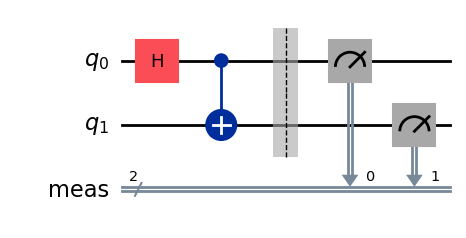

In [94]:
qc = QuantumCircuit(2)
qc.h(0)
qc.cx(0, 1)
qc.measure_all()
qc.draw('mpl')

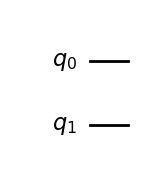

In [95]:
qc = QuantumCircuit(2)
qc.h(0)
qc.clear()
# Circuit should be empty
qc.draw('mpl')

#### Circuit Metrics & Scheduling

Tools to analyze the circuit's properties and timing.

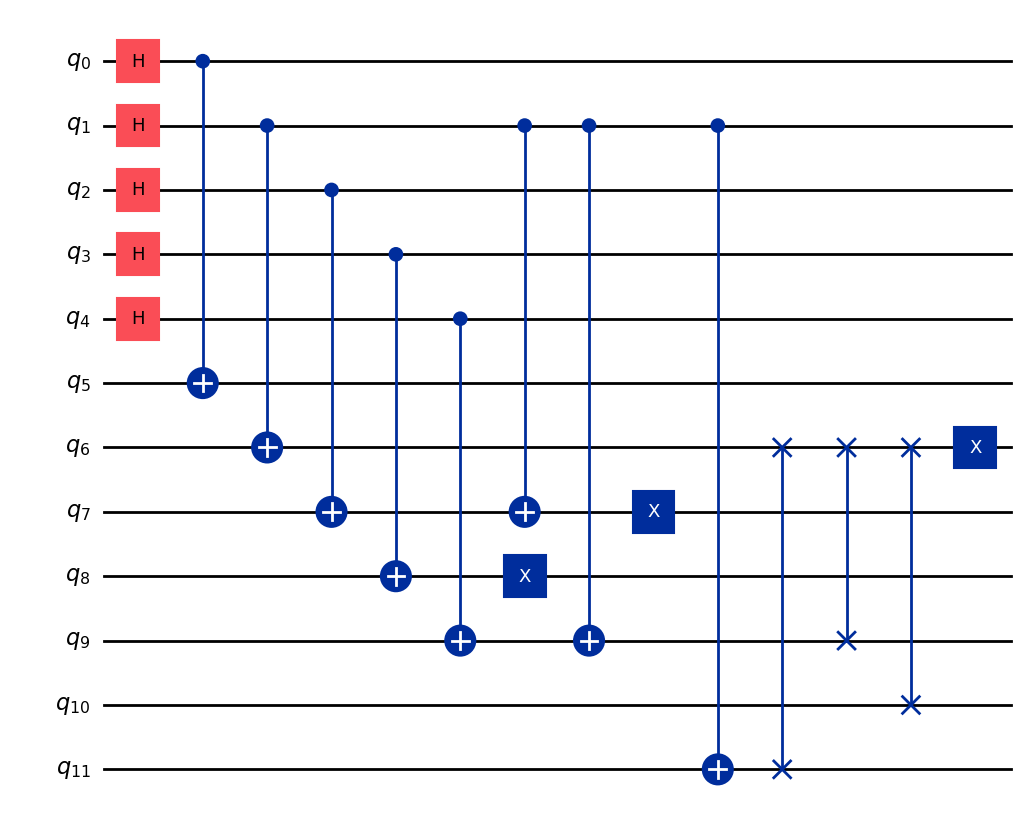

In [96]:
from qiskit import QuantumCircuit
qc = QuantumCircuit(12)
for idx in range(5):
   qc.h(idx)
   qc.cx(idx, idx+5)
 
qc.cx(1, 7)
qc.x(8)
qc.cx(1, 9)
qc.x(7)
qc.cx(1, 11)
qc.swap(6, 11)
qc.swap(6, 9)
qc.swap(6, 10)
qc.x(6)
qc.draw('mpl')

In [97]:
assert qc.width() == 12
assert qc.num_qubits == 12
print(f"Circuit depth: {qc.depth()}")
qc.count_ops()

Circuit depth: 9


OrderedDict([('cx', 8), ('h', 5), ('x', 3), ('swap', 3)])

Accessing Scheduling Information

* estimate_duration
* qubit_duration
* qubit_start_time
* qubit_stop_time

#### estimate_duration

Estimates the total duration of the circuit based on gate times provided by a backend.

In [98]:
from qiskit.providers.fake_provider import GenericBackendV2
qc = QuantumCircuit(1)
qc.delay(100, 0, unit='dt')
# Use at least 2 qubits for the fake backend so multi-qubit basis gates exist
backend = GenericBackendV2(num_qubits=2)
# Pass the backend target (timing info) to estimate_duration
print(f"Duration: {qc.estimate_duration(backend.target)}")

Duration: 2.22e-08


#### qubit_duration

Returns the duration of operations on a specific qubit.

In [99]:
from qiskit.providers.fake_provider import GenericBackendV2
from qiskit.transpiler import generate_preset_pass_manager

# Use a fake backend to simulate real hardware timing
backend = GenericBackendV2(num_qubits=2)

# Transpile and schedule the circuit
pm = generate_preset_pass_manager(target=backend.target, optimization_level=1)
qc_scheduled = pm.run(qc)

# Now we can query duration with valid timing data
print(f"Qubit 0 duration: {qc_scheduled.qubit_duration(0)}")

Qubit 0 duration: 0


Demo qubit 0 duration: 3414
Demo qubit 0 start time: 0
Demo qubit 0 stop time: 3414


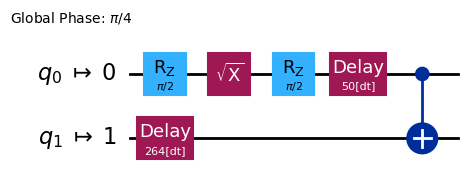

In [100]:
# More illustrative scheduling demo: build a small circuit with gates and delays,
# then schedule it with a fake backend so qubit_duration/start/stop are non-zero.
from qiskit.providers.fake_provider import GenericBackendV2
from qiskit.transpiler import generate_preset_pass_manager
from qiskit import QuantumCircuit

backend = GenericBackendV2(num_qubits=3)
# Use transpile with a scheduling method so start/stop times are populated
from qiskit import transpile

qc_demo = QuantumCircuit(2)
qc_demo.h(0)
qc_demo.delay(50, 0, unit='dt')
qc_demo.cx(0, 1)

# Transpile with scheduling (ALAP) to assign instruction start/stop times
qc_demo_scheduled = transpile(qc_demo, backend=backend, optimization_level=1, scheduling_method='alap')
print("Demo qubit 0 duration:", qc_demo_scheduled.qubit_duration(0))
print("Demo qubit 0 start time:", qc_demo_scheduled.qubit_start_time(0))
print("Demo qubit 0 stop time:", qc_demo_scheduled.qubit_stop_time(0))
qc_demo_scheduled.draw('mpl')


#### qubit_start_time and qubit_stop_time

These methods return the scheduled start and stop times for operations on a specific qubit.

Crucially, these methods will only return non-zero values if the circuit has been transpiled with a scheduling_method (such as 'alap' or 'asap'). The qc_scheduled object from the previous section was created without a scheduling pass, so its timing information remains at the default of zero, as shown below. This contrasts with the qc_demo_scheduled object, which was scheduled and therefore contains valid timing data.


 Note that querying the qc_scheduled object will still yield zero for start and stop times, as the timing information is only present on the new object returned by transpile when a scheduling_method is specified.

In [101]:
# Check start and stop times for Qubit 0
print(f"Qubit 0 start time: {qc_scheduled.qubit_start_time(0)}")
print(f"Qubit 0 stop time: {qc_scheduled.qubit_stop_time(0)}")

Qubit 0 start time: 0
Qubit 0 stop time: 0


#### Instruction Modifiers

Methods that return a new version of the circuit with modified properties (e.g., controlled or inverted).

####  `control()` Method

The `.control()` method is a powerful tool that takes an existing circuit or gate and returns a new version with one or more control qubits. This allows you to easily create controlled versions of complex operations without having to manually decompose them.

In the example below, we start with a simple 1-qubit circuit containing a single Hadamard gate. We then use `.control(1)` to create a new, 2-qubit controlled-Hadamard gate. Notice in the output diagram how the original `h` gate is now represented as a single block with a control point on `q0` acting on the target `q1`.

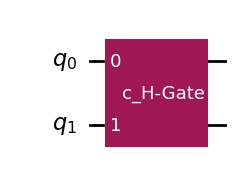

In [102]:
from qiskit import QuantumCircuit

# Create a simple circuit for a single H-gate
qc_h = QuantumCircuit(1, name='H-Gate')
qc_h.h(0)

# Add one control qubit to the H-gate circuit
# The original qubit (0) becomes the target (now on wire 1)
# The new control is on wire 0
controlled_h_gate = qc_h.control(1)

# You can now use this new gate in another circuit
main_qc = QuantumCircuit(2)
main_qc.append(controlled_h_gate, [0, 1])
main_qc.draw('mpl')


####  `inverse()` Method

The `.inverse()` method computes the mathematical inverse (the conjugate transpose, or $U^\dagger$) of a circuit. When applied, it returns a new circuit with all of the gates applied in the reverse order, and with each gate replaced by its own inverse.

This is extremely useful for many algorithms, such as amplitude amplification or algorithms that uncompute a state.

In the example below, notice how the inverted circuit has the `Sdg` (S-dagger) gate and the `H` gate applied in the opposite order of the original.

Original Circuit:


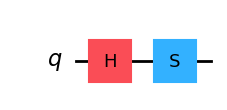


Inverted Circuit:


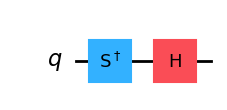

In [103]:
# Create a circuit with a non-symmetrical sequence of gates
qc = QuantumCircuit(1)
qc.h(0)
qc.s(0)

print("Original Circuit:")
display(qc.draw('mpl'))

# Now, compute the inverse
qc_inv = qc.inverse()

print("\nInverted Circuit:")
display(qc_inv.draw('mpl'))

####  `power()` Method

The `.power()` method allows you to raise a gate or circuit to a specific power. This is equivalent to applying the gate's unitary matrix $U$ to itself *n* times ($U^n$).

This is particularly useful for fractional powers or for demonstrating known gate identities. For example, we know that applying a T-gate twice is equivalent to applying a single S-gate ($T^2 = S$). The code below creates a T-gate, raises it to the power of 2, and the resulting circuit diagram correctly shows an S-gate.

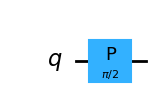

In [104]:
from qiskit.circuit.library import TGate

# Create a circuit with a single T-gate
qc = QuantumCircuit(1)
qc.append(TGate().power(2), [0])

# The output diagram will show an S-gate (Phase Gate where theta=π/2), because T^2 = S
qc.draw('mpl')

####  `reverse_ops()` Method

The `.reverse_ops()` method reverses the order of instructions in a circuit. It is important to note that this **only reverses the order**; it does **not** take the inverse of each gate (unlike the `.inverse()` method).

This is useful for preparing state preparation circuits or for manually constructing certain algorithmic steps. Compare the original circuit to the reversed one below to see the effect.


Original Circuit:


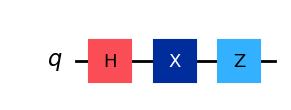


Reversed Circuit:


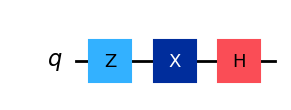

In [105]:
# Create a circuit with a clear sequence of different gates
qc = QuantumCircuit(1)
qc.h(0)
qc.x(0)
qc.z(0)

print("Original Circuit:")
display(qc.draw('mpl'))

# Now, reverse the operations
qc_rev = qc.reverse_ops()

print("\nReversed Circuit:")
display(qc_rev.draw('mpl'))

#### Visualization: Managing Bit Ordering with `reverse_bits`

The `.reverse_bits()` method reverses the order of the qubits in the circuit. This is a crucial helper method for managing Qiskit's bit ordering convention, often referred to as **endianness**.

*   **Qiskit's Default (Little-Endian):** By default, Qiskit uses a little-endian ordering. This means that the qubit at index 0 (`q_0`) is the *least significant bit* (LSB) when representing a quantum state as a binary string. For example, the state $|101\rangle$ would be represented by `q_2=1`, `q_1=0`, `q_0=1`.

*   **Textbook Convention (Big-Endian):** However, many quantum algorithms, textbooks, and academic papers use a big-endian convention, where `q_0` is the *most significant bit* (MSB). In this convention, $|101\rangle$ would be represented by `q_0=1`, `q_1=0`, `q_2=1`.

The `reverse_bits()` method provides a simple way to switch between these two conventions for visualization or before performing certain operations, without having to rebuild the circuit.

In the demonstration below, we create a 3-qubit circuit and apply an `X` gate to `q_0` and a `Z` gate to `q_2`. After reversing, notice how the `X` gate now appears on the `q_2` wire and the `Z` gate on the `q_0` wire in the new diagram, because the bit objects themselves have been re-ordered internally.


Original Circuit (Default Little-Endian Ordering):


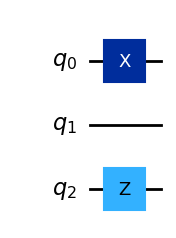


Circuit After reverse_bits() (Big-Endian Ordering):


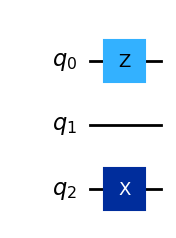

In [106]:
# Create a 3-qubit circuit to clearly show the reversal
qc = QuantumCircuit(3)

# Apply a distinctive gate to the first and last qubits
qc.x(0)
qc.z(2)

print("Original Circuit (Default Little-Endian Ordering):")
display(qc.draw('mpl'))

# Now, reverse the order of the bits
qc_reversed = qc.reverse_bits()

print("\nCircuit After reverse_bits() (Big-Endian Ordering):")
display(qc_reversed.draw('mpl'))